In [11]:
import sys
import os
# Add parent directory to path to import tradingutils modules
sys.path.insert(0, os.path.abspath('..'))

from kalshi_utils.client_wrapper import *

In [12]:
kalshi_wrapped = KalshiWrapped()

Client Created


In [13]:
nhl_live_markets = kalshi_wrapped.GetAllNHLMarkets(status="open")

In [14]:
kalshi_wrapped.GetMarketPairs(nhl_live_markets)

[(Market(ticker='KXNHLGAME-26JAN22DETMIN-MIN', event_ticker='KXNHLGAME-26JAN22DETMIN', market_type='binary', title='Detroit at Minnesota Winner?', subtitle='', yes_sub_title='MIN Wild', no_sub_title='MIN Wild', created_time=datetime.datetime(2026, 1, 20, 5, 1, 41, 907604, tzinfo=TzInfo(0)), open_time=datetime.datetime(2026, 1, 20, 10, 6, tzinfo=TzInfo(0)), close_time=datetime.datetime(2026, 2, 6, 2, 30, tzinfo=TzInfo(0)), expected_expiration_time=datetime.datetime(2026, 1, 23, 5, 30, tzinfo=TzInfo(0)), expiration_time=datetime.datetime(2026, 2, 6, 2, 30, tzinfo=TzInfo(0)), latest_expiration_time=datetime.datetime(2026, 2, 6, 2, 30, tzinfo=TzInfo(0)), settlement_timer_seconds=30, status='active', response_price_units='usd_cent', yes_bid=52, yes_bid_dollars='0.5200', yes_ask=57, yes_ask_dollars='0.5700', no_bid=43, no_bid_dollars='0.4300', no_ask=48, no_ask_dollars='0.4800', last_price=57, last_price_dollars='0.5700', volume=5, volume_24h=5, result='', can_close_early=True, open_interest

In [15]:
valid = kalshi_wrapped.GetPairWithTeam(kalshi_wrapped.GetMarketPairs(nhl_live_markets), "Jackets")
valid

[(Market(ticker='KXNHLGAME-26JAN22DALCBJ-DAL', event_ticker='KXNHLGAME-26JAN22DALCBJ', market_type='binary', title='Dallas at Columbus Winner?', subtitle='', yes_sub_title='DAL Stars', no_sub_title='DAL Stars', created_time=datetime.datetime(2026, 1, 20, 2, 1, 43, 862072, tzinfo=TzInfo(0)), open_time=datetime.datetime(2026, 1, 20, 7, 6, tzinfo=TzInfo(0)), close_time=datetime.datetime(2026, 2, 6, 0, 0, tzinfo=TzInfo(0)), expected_expiration_time=datetime.datetime(2026, 1, 23, 3, 0, tzinfo=TzInfo(0)), expiration_time=datetime.datetime(2026, 2, 6, 0, 0, tzinfo=TzInfo(0)), latest_expiration_time=datetime.datetime(2026, 2, 6, 0, 0, tzinfo=TzInfo(0)), settlement_timer_seconds=30, status='active', response_price_units='usd_cent', yes_bid=53, yes_bid_dollars='0.5300', yes_ask=56, yes_ask_dollars='0.5600', no_bid=44, no_bid_dollars='0.4400', no_ask=47, no_ask_dollars='0.4700', last_price=56, last_price_dollars='0.5600', volume=421, volume_24h=421, result='', can_close_early=True, open_interest=

In [16]:
target = valid[1]

In [17]:
import time, math, threading
from collections import deque
from datetime import datetime
import uuid
import os
import logging

%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ---------- logging setup ----------
def setup_logger(notebook_dir: str) -> logging.Logger:
    """Create a logger that writes to a log file with date and UUID"""
    log_dir = os.path.join(notebook_dir, "logs")
    os.makedirs(log_dir, exist_ok=True)
    
    session_id = str(uuid.uuid4())[:8]
    date_str = datetime.now().strftime("%Y-%m-%d")
    log_filename = f"arb_monitor_{date_str}_{session_id}.log"
    log_path = os.path.join(log_dir, log_filename)
    
    logger = logging.getLogger(f"arb_monitor_{session_id}")
    logger.setLevel(logging.DEBUG)
    
    # Clear existing handlers
    logger.handlers = []
    
    # File handler
    fh = logging.FileHandler(log_path)
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(logging.Formatter('%(asctime)s | %(levelname)s | %(message)s'))
    logger.addHandler(fh)
    
    # Console handler for important messages
    ch = logging.StreamHandler()
    ch.setLevel(logging.INFO)
    ch.setFormatter(logging.Formatter('%(message)s'))
    logger.addHandler(ch)
    
    logger.info(f"=== Logging started: {log_path} ===")
    return logger

# Get notebook directory for logging
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()

# ---------- helpers ----------
def _to_float(x):
    if x is None:
        return None
    try:
        return float(x)
    except (TypeError, ValueError):
        return None

def _round_up_cent(x: float) -> float:
    return math.ceil(x * 100.0) / 100.0

def kalshi_fee_total(C: int, P: float, maker: bool = False) -> float:
    # Taker: round_up(0.07*C*P*(1-P)), Maker: round_up(0.0175*C*P*(1-P))
    rate = 0.0175 if maker else 0.07
    return _round_up_cent(rate * C * P * (1.0 - P))

def fee_per_contract(C: int, P: float, maker: bool = False) -> float:
    return kalshi_fee_total(C, P, maker=maker) / C

def all_in_buy_cost(P_ask: float, C: int, maker: bool = False) -> float:
    # cost per contract to buy now at ask, including fees
    return P_ask + fee_per_contract(C, P_ask, maker=maker)

def all_in_sell_proceeds(P_bid: float, C: int, maker: bool = False) -> float:
    # proceeds per contract to sell now at bid, net of fees
    return P_bid - fee_per_contract(C, P_bid, maker=maker)

# ---------- live monitor ----------
class LiveArbMonitor:
    def __init__(
        self,
        client,
        ticker_1: str,       # market1
        ticker_2: str,       # market2
        poll_period_ms: int = 500,
        contract_size: int = 100,
        entry_maker: bool = False,   # if you cross spread, this should be False (taker)
        exit_maker: bool = False,    # same idea for selling
        min_edge: float = 0.01,      # for routing prints (optional)
        arb_floor: float = 0.002,    # only print arb if pnl >= this ($/contract)
        profit_floor: float = 0.002, # only print dutch-to-settle if profit >= this
        history: int = 600,
        auto_trade: bool = False,    # enable automatic trading
        max_position: int = 10,      # max contracts per leg
        trade_size: int = 1,         # contracts per trade
        min_trade_pnl: float = 0.005, # minimum pnl to execute trade ($/contract)
        logger: logging.Logger = None,
    ):
        self.client = client
        self.t_1 = ticker_1
        self.t_2 = ticker_2
        
        # Setup logger
        self.logger = logger or setup_logger(NOTEBOOK_DIR)
        self.logger.info(f"LiveArbMonitor initialized: {ticker_1} vs {ticker_2}")
        self.logger.info(f"Settings: auto_trade={auto_trade}, trade_size={trade_size}, max_position={max_position}")
        self.logger.info(f"Thresholds: min_trade_pnl={min_trade_pnl}, arb_floor={arb_floor}, profit_floor={profit_floor}")
        self.client = client
        self.t_1 = ticker_1
        self.t_2 = ticker_2

        self.poll_period_s = poll_period_ms / 1000.0
        self.C = contract_size
        self.entry_maker = entry_maker
        self.exit_maker = exit_maker
        self.min_edge = min_edge
        self.arb_floor = arb_floor
        self.profit_floor = profit_floor
        
        # Trading controls
        self.auto_trade = auto_trade
        self.max_position = max_position
        self.trade_size = trade_size
        self.min_trade_pnl = min_trade_pnl
        
        # Position tracking
        self.positions = {
            f"{ticker_1}_yes": 0,
            f"{ticker_1}_no": 0,
            f"{ticker_2}_yes": 0,
            f"{ticker_2}_no": 0,
        }
        self.trade_history = []
        self.last_trade_time = 0
        self.trade_cooldown = 2.0  # seconds between trades

        self.lock = threading.Lock()
        self.stop_evt = threading.Event()
        self.t0 = time.time()

        self.x = deque(maxlen=history)

        # routing edges (entry-cost only; still useful)
        self.edge_1 = deque(maxlen=history)
        self.edge_2 = deque(maxlen=history)

        # "dutch to settle" profit (entry only)
        self.profit_to_settle = deque(maxlen=history)

        # cross-market arb pnl per contract (buy cheap exposure, sell expensive exposure)
        self.arb_pnl_1 = deque(maxlen=history)
        self.arb_pnl_2 = deque(maxlen=history)

        # entry fees per contract (at asks)
        self.f_1_yes = deque(maxlen=history)
        self.f_1_no  = deque(maxlen=history)
        self.f_2_yes = deque(maxlen=history)
        self.f_2_no  = deque(maxlen=history)

        # best-action tracking
        self.best_kind = "NO_TRADE"
        self.best_since = time.time()

        self.last_meta = {
            "team1": "Team 1", "team2": "Team 2",
            "t1_yes_a": None, "t1_no_a": None, "t2_yes_a": None, "t2_no_a": None,
            "t1_yes_b": None, "t1_no_b": None, "t2_yes_b": None, "t2_no_b": None,
            "arb_leg_1_buy": "", "arb_leg_1_sell": "",
            "arb_leg_2_buy": "", "arb_leg_2_sell": "",
            "best_action": "NO_TRADE",
            "best_value": 0.0,
            "best_age_s": 0.0,
        }

        self.last_sig = {"team1": None, "team2": None, "dutch": None}
        self.th = threading.Thread(target=self._run, daemon=True)

    def start(self):
        self.th.start()
        return self

    def stop(self):
        self.stop_evt.set()
        self.th.join(timeout=2.0)
        self.logger.info("Monitor stopped")
    
    def _execute_trade(self, ticker: str, side: str, action: str, price: float, quantity: int):
        """Execute a single trade leg"""
        try:
            # side = "yes" or "no", action = "buy" or "sell"
            order_params = {
                "ticker": ticker,
                "action": action,
                "side": side,
                "count": quantity,
                "type": "market" if not self.entry_maker else "limit",
            }
            
            if self.entry_maker:
                order_params["yes_price"] = int(price * 100) if side == "yes" else None
                order_params["no_price"] = int(price * 100) if side == "no" else None
            
            ts = datetime.now().strftime("%H:%M:%S")
            msg = f"[{ts}] EXECUTING: {action.upper()} {quantity} {side.upper()} {ticker} @ {price:.3f}"
            print(msg)
            self.logger.info(msg)
            self.logger.debug(f"Order params: {order_params}")
            
            # Place order through client
            response = self.client.create_order(**order_params)
            
            # Update position tracking
            pos_key = f"{ticker}_{side}"
            if action == "buy":
                self.positions[pos_key] += quantity
            else:
                self.positions[pos_key] -= quantity
            
            # Record trade
            trade_record = {
                "time": time.time(),
                "ticker": ticker,
                "side": side,
                "action": action,
                "quantity": quantity,
                "price": price,
                "response": str(response),
            }
            self.trade_history.append(trade_record)
            
            msg = f"[{ts}] ✓ Trade executed. Position {pos_key}: {self.positions[pos_key]}"
            print(msg)
            self.logger.info(msg)
            self.logger.debug(f"Response: {response}")
            return True
            
        except Exception as e:
            msg = f"[TRADE ERROR] {ticker} {side} {action}: {e}"
            print(msg)
            self.logger.error(msg, exc_info=True)
            return False
    
    def _can_trade(self, ticker: str, side: str, quantity: int):
        """Check if trade is within position limits"""
        pos_key = f"{ticker}_{side}"
        new_position = self.positions[pos_key] + quantity
        can = abs(new_position) <= self.max_position
        if not can:
            self.logger.debug(f"Position limit check FAILED: {pos_key} current={self.positions[pos_key]} + {quantity} = {new_position}, max={self.max_position}")
        return can
    
    def _execute_arb(self, buy_ticker: str, buy_side: str, buy_price: float,
                     sell_ticker: str, sell_side: str, sell_price: float, 
                     expected_pnl: float, team_name: str):
        """Execute a cross-market arb trade"""
        ts = datetime.now().strftime("%H:%M:%S")
        
        # Check cooldown
        time_since_last = time.time() - self.last_trade_time
        if time_since_last < self.trade_cooldown:
            self.logger.debug(f"Cooldown active: {time_since_last:.1f}s < {self.trade_cooldown}s")
            return False
        
        # Check position limits
        if not self._can_trade(buy_ticker, buy_side, self.trade_size):
            msg = f"[{ts}] Position limit reached for {buy_ticker} {buy_side}"
            print(msg)
            self.logger.warning(msg)
            return False
        if not self._can_trade(sell_ticker, sell_side, -self.trade_size):
            msg = f"[{ts}] Position limit reached for {sell_ticker} {sell_side}"
            print(msg)
            self.logger.warning(msg)
            return False
        
        msg = f"\n[{ts}] ═══ EXECUTING ARB: {team_name} exposure ═══"
        print(msg)
        self.logger.info(msg)
        msg = f"Expected PnL: ${expected_pnl:.4f}/contract, Total: ${expected_pnl * self.trade_size:.2f}"
        print(msg)
        self.logger.info(msg)
        
        # Execute buy leg first
        buy_success = self._execute_trade(buy_ticker, buy_side, "buy", buy_price, self.trade_size)
        if not buy_success:
            msg = f"[{ts}] ✗ Buy leg failed, aborting arb"
            print(msg)
            self.logger.error(msg)
            return False
        
        # Execute sell leg
        sell_success = self._execute_trade(sell_ticker, sell_side, "sell", sell_price, self.trade_size)
        if not sell_success:
            msg = f"[{ts}] ⚠ Sell leg failed! Holding unhedged position!"
            print(msg)
            self.logger.error(msg)
            return False
        
        self.last_trade_time = time.time()
        msg = f"[{ts}] ═══ ARB COMPLETE ═══\n"
        print(msg)
        self.logger.info(msg)
        return True
    
    def _execute_dutch_settle(self, leg1_ticker: str, leg1_side: str, leg1_price: float,
                               leg2_ticker: str, leg2_side: str, leg2_price: float,
                               expected_profit: float):
        """Execute dutch auction to settlement trade"""
        ts = datetime.now().strftime("%H:%M:%S")
        
        # Check cooldown
        time_since_last = time.time() - self.last_trade_time
        if time_since_last < self.trade_cooldown:
            self.logger.debug(f"Cooldown active: {time_since_last:.1f}s < {self.trade_cooldown}s")
            return False
        
        # Check position limits
        if not self._can_trade(leg1_ticker, leg1_side, self.trade_size):
            msg = f"[{ts}] Position limit reached for {leg1_ticker} {leg1_side}"
            print(msg)
            self.logger.warning(msg)
            return False
        if not self._can_trade(leg2_ticker, leg2_side, self.trade_size):
            msg = f"[{ts}] Position limit reached for {leg2_ticker} {leg2_side}"
            print(msg)
            self.logger.warning(msg)
            return False
        
        msg = f"\n[{ts}] ═══ EXECUTING DUTCH-TO-SETTLE ═══"
        print(msg)
        self.logger.info(msg)
        msg = f"Expected Profit: ${expected_profit:.4f}/contract, Total: ${expected_profit * self.trade_size:.2f}"
        print(msg)
        self.logger.info(msg)
        
        # Execute both buy legs
        leg1_success = self._execute_trade(leg1_ticker, leg1_side, "buy", leg1_price, self.trade_size)
        if not leg1_success:
            msg = f"[{ts}] ✗ Leg 1 failed, aborting"
            print(msg)
            self.logger.error(msg)
            return False
        
        leg2_success = self._execute_trade(leg2_ticker, leg2_side, "buy", leg2_price, self.trade_size)
        if not leg2_success:
            msg = f"[{ts}] ⚠ Leg 2 failed! Holding partial position!"
            print(msg)
            self.logger.error(msg)
            return False
        
        self.last_trade_time = time.time()
        msg = f"[{ts}] ═══ DUTCH-TO-SETTLE COMPLETE ═══\n"
        print(msg)
        self.logger.info(msg)
        return True

    def _run(self):
        while not self.stop_evt.is_set():
            try:
                m_1 = self.client.get_market(self.t_1)
                m_2 = self.client.get_market(self.t_2)

                d_1 = m_1.market.model_dump()
                d_2 = m_2.market.model_dump()

                team1 = d_1.get("yes_sub_title", "Team 1")
                team2 = d_2.get("yes_sub_title", "Team 2")

                # asks
                t1_yes_a = _to_float(d_1.get("yes_ask_dollars"))
                t1_no_a  = _to_float(d_1.get("no_ask_dollars"))
                t2_yes_a = _to_float(d_2.get("yes_ask_dollars"))
                t2_no_a  = _to_float(d_2.get("no_ask_dollars"))

                # bids
                t1_yes_b = _to_float(d_1.get("yes_bid_dollars"))
                t1_no_b  = _to_float(d_1.get("no_bid_dollars"))
                t2_yes_b = _to_float(d_2.get("yes_bid_dollars"))
                t2_no_b  = _to_float(d_2.get("no_bid_dollars"))

                if any(v is None for v in [t1_yes_a, t1_no_a, t2_yes_a, t2_no_a]):
                    self.logger.warning(f"Missing asks: t1_yes_a={t1_yes_a}, t1_no_a={t1_no_a}, t2_yes_a={t2_yes_a}, t2_no_a={t2_no_a}")
                    time.sleep(self.poll_period_s)
                    continue
                
                # Log market state periodically (every 10 ticks)
                if len(self.x) % 10 == 0:
                    self.logger.debug(f"Market state: t1_yes a/b={t1_yes_a}/{t1_yes_b}, t1_no a/b={t1_no_a}/{t1_no_b}, t2_yes a/b={t2_yes_a}/{t2_yes_b}, t2_no a/b={t2_no_a}/{t2_no_b}")

                # ----- entry all-in costs (per contract) -----
                c_1_yes = all_in_buy_cost(t1_yes_a, self.C, maker=self.entry_maker)
                c_1_no  = all_in_buy_cost(t1_no_a,  self.C, maker=self.entry_maker)
                c_2_yes = all_in_buy_cost(t2_yes_a, self.C, maker=self.entry_maker)
                c_2_no  = all_in_buy_cost(t2_no_a,  self.C, maker=self.entry_maker)

                # routing edges (same exposure, different instrument)
                edge_1 = c_1_yes - c_2_no     # Team1 exposure: YES Team1 vs NO Team2
                edge_2 = c_2_yes - c_1_no     # Team2 exposure: YES Team2 vs NO Team1

                # dutch-to-settle
                best_1 = min(c_1_yes, c_2_no)
                best_2 = min(c_2_yes, c_1_no)
                profit_to_settle = 1.0 - (best_1 + best_2)

                # ----- cross-market arb PnL (buy cheap exposure, sell expensive exposure) -----
                arb_pnl_1 = None
                arb_buy_1 = arb_sell_1 = ""

                if (t1_yes_b is not None) and (t2_no_b is not None):
                    buy_candidates = [
                        ("BUY YES", self.t_1, t1_yes_a, c_1_yes),
                        ("BUY NO",  self.t_2, t2_no_a, c_2_no),
                    ]
                    sell_candidates = [
                        ("SELL YES", self.t_1, t1_yes_b, all_in_sell_proceeds(t1_yes_b, self.C, maker=self.exit_maker)),
                        ("SELL NO",  self.t_2, t2_no_b, all_in_sell_proceeds(t2_no_b, self.C, maker=self.exit_maker)),
                    ]
                    buy_leg = min(buy_candidates, key=lambda x: x[3])
                    sell_leg = max(sell_candidates, key=lambda x: x[3])
                    arb_pnl_1 = sell_leg[3] - buy_leg[3]
                    arb_buy_1 = f"{buy_leg[0]} {buy_leg[1]} @ {buy_leg[2]:.3f}"
                    arb_sell_1 = f"{sell_leg[0]} {sell_leg[1]} @ {sell_leg[2]:.3f}"

                arb_pnl_2 = None
                arb_buy_2 = arb_sell_2 = ""

                if (t2_yes_b is not None) and (t1_no_b is not None):
                    buy_candidates = [
                        ("BUY YES", self.t_2, t2_yes_a, c_2_yes),
                        ("BUY NO",  self.t_1, t1_no_a,  c_1_no),
                    ]
                    sell_candidates = [
                        ("SELL YES", self.t_2, t2_yes_b, all_in_sell_proceeds(t2_yes_b, self.C, maker=self.exit_maker)),
                        ("SELL NO",  self.t_1, t1_no_b,  all_in_sell_proceeds(t1_no_b,  self.C, maker=self.exit_maker)),
                    ]
                    buy_leg = min(buy_candidates, key=lambda x: x[3])
                    sell_leg = max(sell_candidates, key=lambda x: x[3])
                    arb_pnl_2 = sell_leg[3] - buy_leg[3]
                    arb_buy_2 = f"{buy_leg[0]} {buy_leg[1]} @ {buy_leg[2]:.3f}"
                    arb_sell_2 = f"{sell_leg[0]} {sell_leg[1]} @ {sell_leg[2]:.3f}"

                # ----- choose best action NOW (this tick) -----
                candidates = []

                if (arb_pnl_1 is not None) and (arb_pnl_1 >= self.arb_floor):
                    candidates.append(("ARB_TEAM1", arb_pnl_1, f"{arb_buy_1} ; {arb_sell_1}"))

                if (arb_pnl_2 is not None) and (arb_pnl_2 >= self.arb_floor):
                    candidates.append(("ARB_TEAM2", arb_pnl_2, f"{arb_buy_2} ; {arb_sell_2}"))

                if profit_to_settle >= self.profit_floor:
                    candidates.append(("DUTCH_SETTLE", profit_to_settle, "Buy both cheapest legs; hold to settlement"))

                now = time.time()
                if candidates:
                    best_kind, best_val, best_detail = max(candidates, key=lambda t: t[1])
                    best_action_str = f"{best_kind}: {best_detail}"
                else:
                    best_kind, best_val, best_action_str = "NO_TRADE", 0.0, "NO_TRADE: No action clears thresholds"

                if best_kind != self.best_kind:
                    self.best_kind = best_kind
                    self.best_since = now
                best_age_s = now - self.best_since

                with self.lock:
                    self.x.append(now - self.t0)
                    self.edge_1.append(edge_1)
                    self.edge_2.append(edge_2)
                    self.profit_to_settle.append(profit_to_settle)

                    self.arb_pnl_1.append(arb_pnl_1 if arb_pnl_1 is not None else float("nan"))
                    self.arb_pnl_2.append(arb_pnl_2 if arb_pnl_2 is not None else float("nan"))

                    self.f_1_yes.append(fee_per_contract(self.C, t1_yes_a, maker=self.entry_maker))
                    self.f_1_no.append( fee_per_contract(self.C, t1_no_a,  maker=self.entry_maker))
                    self.f_2_yes.append(fee_per_contract(self.C, t2_yes_a, maker=self.entry_maker))
                    self.f_2_no.append( fee_per_contract(self.C, t2_no_a,  maker=self.entry_maker))

                    self.last_meta.update({
                        "team1": team1, "team2": team2,
                        "t1_yes_a": t1_yes_a, "t1_no_a": t1_no_a, "t2_yes_a": t2_yes_a, "t2_no_a": t2_no_a,
                        "t1_yes_b": t1_yes_b, "t1_no_b": t1_no_b, "t2_yes_b": t2_yes_b, "t2_no_b": t2_no_b,
                        "arb_leg_1_buy": arb_buy_1, "arb_leg_1_sell": arb_sell_1,
                        "arb_leg_2_buy": arb_buy_2, "arb_leg_2_sell": arb_sell_2,
                        "best_action": best_action_str,
                        "best_value": float(best_val),
                        "best_age_s": float(best_age_s),
                    })

                # ----- prints: what to do -----
                ts = datetime.now().strftime("%H:%M:%S")

                if abs(edge_1) >= self.min_edge:
                    sig = (f"[{ts}] {team1} exposure cheaper via "
                           f"{'BUY NO '+self.t_2 if edge_1>0 else 'BUY YES '+self.t_1} "
                           f"(edge={abs(edge_1):.4f} $/contract, fees incl.)")
                    if sig != self.last_sig["team1"]:
                        print(sig)
                        self.last_sig["team1"] = sig

                if abs(edge_2) >= self.min_edge:
                    sig = (f"[{ts}] {team2} exposure cheaper via "
                           f"{'BUY NO '+self.t_1 if edge_2>0 else 'BUY YES '+self.t_2} "
                           f"(edge={abs(edge_2):.4f} $/contract, fees incl.)")
                    if sig != self.last_sig["team2"]:
                        print(sig)
                        self.last_sig["team2"] = sig

                if (arb_pnl_1 is not None) and (arb_pnl_1 >= self.arb_floor):
                    print(f"[{ts}] ARB {team1} exposure: {arb_buy_1} ; {arb_sell_1} "
                          f"=> pnl≈{arb_pnl_1:.4f} $/contract (fees entry+exit incl.)")

                if (arb_pnl_2 is not None) and (arb_pnl_2 >= self.arb_floor):
                    print(f"[{ts}] ARB {team2} exposure: {arb_buy_2} ; {arb_sell_2} "
                          f"=> pnl≈{arb_pnl_2:.4f} $/contract (fees entry+exit incl.)")

                if profit_to_settle >= self.profit_floor:
                    print(f"[{ts}] DUTCH-to-settle: profit≈{profit_to_settle:.4f} $/contract "
                          f"(assumes {team1}/{team2} are perfect complements)")

                # ----- AUTO TRADING: Execute best action if enabled -----
                if self.auto_trade and candidates:
                    best_kind, best_val, _ = max(candidates, key=lambda t: t[1])
                    
                    self.logger.debug(f"AUTO_TRADE check: best_kind={best_kind}, best_val={best_val:.5f}, min_trade_pnl={self.min_trade_pnl}")
                    
                    if best_val >= self.min_trade_pnl:
                        self.logger.info(f"TRADE SIGNAL: {best_kind} with pnl={best_val:.5f} >= {self.min_trade_pnl}")
                        
                        if best_kind == "ARB_TEAM1" and arb_pnl_1 >= self.min_trade_pnl:
                            # Parse which legs to trade from the candidates
                            buy_candidates = [
                                (self.t_1, "yes", t1_yes_a),
                                (self.t_2, "no", t2_no_a),
                            ]
                            sell_candidates = [
                                (self.t_1, "yes", t1_yes_b),
                                (self.t_2, "no", t2_no_b),
                            ]
                            self.logger.debug(f"ARB_TEAM1 buy_candidates: {buy_candidates}")
                            self.logger.debug(f"ARB_TEAM1 sell_candidates: {sell_candidates}")
                            
                            buy_leg = min(buy_candidates, key=lambda x: all_in_buy_cost(x[2], self.C, self.entry_maker))
                            sell_leg = max(sell_candidates, key=lambda x: all_in_sell_proceeds(x[2], self.C, self.exit_maker))
                            
                            self.logger.info(f"Executing ARB_TEAM1: BUY {buy_leg}, SELL {sell_leg}")
                            
                            self._execute_arb(
                                buy_leg[0], buy_leg[1], buy_leg[2],
                                sell_leg[0], sell_leg[1], sell_leg[2],
                                arb_pnl_1, team1
                            )
                        
                        elif best_kind == "ARB_TEAM2" and arb_pnl_2 >= self.min_trade_pnl:
                            buy_candidates = [
                                (self.t_2, "yes", t2_yes_a),
                                (self.t_1, "no", t1_no_a),
                            ]
                            sell_candidates = [
                                (self.t_2, "yes", t2_yes_b),
                                (self.t_1, "no", t1_no_b),
                            ]
                            self.logger.debug(f"ARB_TEAM2 buy_candidates: {buy_candidates}")
                            self.logger.debug(f"ARB_TEAM2 sell_candidates: {sell_candidates}")
                            
                            buy_leg = min(buy_candidates, key=lambda x: all_in_buy_cost(x[2], self.C, self.entry_maker))
                            sell_leg = max(sell_candidates, key=lambda x: all_in_sell_proceeds(x[2], self.C, self.exit_maker))
                            
                            self.logger.info(f"Executing ARB_TEAM2: BUY {buy_leg}, SELL {sell_leg}")
                            
                            self._execute_arb(
                                buy_leg[0], buy_leg[1], buy_leg[2],
                                sell_leg[0], sell_leg[1], sell_leg[2],
                                arb_pnl_2, team2
                            )
                        
                        elif best_kind == "DUTCH_SETTLE" and profit_to_settle >= self.min_trade_pnl:
                            # Buy both cheapest legs
                            leg1 = (self.t_1, "yes", t1_yes_a) if c_1_yes < c_2_no else (self.t_2, "no", t2_no_a)
                            leg2 = (self.t_2, "yes", t2_yes_a) if c_2_yes < c_1_no else (self.t_1, "no", t1_no_a)
                            
                            self.logger.info(f"Executing DUTCH_SETTLE: leg1={leg1}, leg2={leg2}")
                            
                            self._execute_dutch_settle(
                                leg1[0], leg1[1], leg1[2],
                                leg2[0], leg2[1], leg2[2],
                                profit_to_settle
                            )
                    else:
                        self.logger.debug(f"Below threshold: {best_val:.5f} < {self.min_trade_pnl}")
                elif self.auto_trade:
                    self.logger.debug(f"No candidates this tick. arb_pnl_1={arb_pnl_1}, arb_pnl_2={arb_pnl_2}, profit_to_settle={profit_to_settle:.5f}")
                    self.logger.debug(f"Bids: t1_yes_b={t1_yes_b}, t1_no_b={t1_no_b}, t2_yes_b={t2_yes_b}, t2_no_b={t2_no_b}")

            except Exception as e:
                msg = f"[poll error] {e}"
                print(msg)
                self.logger.error(msg, exc_info=True)

            time.sleep(self.poll_period_s)

# ---------- plot wiring ----------
def live_plot_pair(
    event_pair,
    poll_period_ms=500,
    contract_size=100,
    entry_maker=False,
    exit_maker=False,
    min_edge=0.01,
    arb_floor=0.002,
    profit_floor=0.002,
    history=600,
    refresh_ms=250,
    auto_trade=False,        # NEW: enable auto trading
    max_position=10,         # NEW: max contracts per leg
    trade_size=1,            # NEW: contracts per trade
    min_trade_pnl=0.005,     # NEW: min pnl to execute
):
    market1, market2 = event_pair
    t_1 = market1.model_dump()["ticker"]
    t_2 = market2.model_dump()["ticker"]
    
    # Setup logger for this session
    logger = setup_logger(NOTEBOOK_DIR)
    logger.info(f"Starting live_plot_pair for {t_1} vs {t_2}")

    mon = LiveArbMonitor(
        client=kalshi_wrapped.GetClient(),
        ticker_1=t_1,
        ticker_2=t_2,
        poll_period_ms=poll_period_ms,
        contract_size=contract_size,
        entry_maker=entry_maker,
        exit_maker=exit_maker,
        min_edge=min_edge,
        arb_floor=arb_floor,
        profit_floor=profit_floor,
        history=history,
        auto_trade=auto_trade,
        max_position=max_position,
        trade_size=trade_size,
        min_trade_pnl=min_trade_pnl,
        logger=logger,
    ).start()

    fig, ax = plt.subplots()

    # left axis: profitability signals
    (l_edge_1,) = ax.plot([], [], label="Team1 routing edge")
    (l_edge_2,) = ax.plot([], [], label="Team2 routing edge")
    (l_arb_1,) = ax.plot([], [], label="ARB pnl Team1 exposure")
    (l_arb_2,) = ax.plot([], [], label="ARB pnl Team2 exposure")
    (l_dutch,) = ax.plot([], [], label="profit_to_settle")

    ax.axhline(0.0)
    ax.axhline(arb_floor)
    ax.axhline(profit_floor)

    ax.set_xlabel("seconds")
    ax.set_ylabel("$/contract (fees included)")
    title = ax.set_title("Starting...")

    # overlay text for best action + age
    action_text = ax.text(
        0.02, 0.02, "",
        transform=ax.transAxes,
        va="bottom", ha="left",
    )

    # right axis: entry fees at asks
    axf = ax.twinx()
    (f1,) = axf.plot([], [], linestyle="--", label="fee Team1 YES@ask")
    (f2,) = axf.plot([], [], linestyle="--", label="fee Team1 NO@ask")
    (f3,) = axf.plot([], [], linestyle="--", label="fee Team2 YES@ask")
    (f4,) = axf.plot([], [], linestyle="--", label="fee Team2 NO@ask")
    axf.set_ylabel("fee per contract ($)")

    leg_left = ax.legend(loc="upper left")
    leg_right = axf.legend(loc="upper right")
    last_names = {"team1": None, "team2": None}

    def _update(_frame):
        nonlocal leg_left

        with mon.lock:
            xs = list(mon.x)
            e_1 = list(mon.edge_1)
            e_2 = list(mon.edge_2)
            a_1 = list(mon.arb_pnl_1)
            a_2 = list(mon.arb_pnl_2)
            dutch = list(mon.profit_to_settle)

            ff1 = list(mon.f_1_yes)
            ff2 = list(mon.f_1_no)
            ff3 = list(mon.f_2_yes)
            ff4 = list(mon.f_2_no)

            meta = dict(mon.last_meta)

        if not xs:
            return (l_edge_1, l_edge_2, l_arb_1, l_arb_2, l_dutch, f1, f2, f3, f4, title, action_text, leg_left, leg_right)

        l_edge_1.set_data(xs, e_1)
        l_edge_2.set_data(xs, e_2)
        l_arb_1.set_data(xs, a_1)
        l_arb_2.set_data(xs, a_2)
        l_dutch.set_data(xs, dutch)

        f1.set_data(xs, ff1)
        f2.set_data(xs, ff2)
        f3.set_data(xs, ff3)
        f4.set_data(xs, ff4)

        ax.set_xlim(xs[0], xs[-1])

        # autoscale left axis
        ys = [v for series in (e_1, e_2, a_1, a_2, dutch)
              for v in series
              if (v is not None and not (isinstance(v, float) and math.isnan(v)))]
        if ys:
            ymin = min(min(ys), 0.0) - 0.01
            ymax = max(max(ys), arb_floor, profit_floor, 0.0) + 0.01
            ax.set_ylim(ymin, ymax)

        # autoscale fee axis (stable)
        if ff1 and ff2 and ff3 and ff4:
            fmin = min(ff1[-1], ff2[-1], ff3[-1], ff4[-1])
            fmax = max(ff1[-1], ff2[-1], ff3[-1], ff4[-1])
            axf.set_ylim(max(0.0, fmin - 0.001), fmax + 0.001)

        # update legend labels to include team names
        if meta["team1"] != last_names["team1"] or meta["team2"] != last_names["team2"]:
            l_edge_1.set_label(f"{meta['team1']} routing edge: all-in(YES {t_1}) - all-in(NO {t_2})")
            l_edge_2.set_label(f"{meta['team2']} routing edge: all-in(YES {t_2}) - all-in(NO {t_1})")
            l_arb_1.set_label(f"ARB pnl {meta['team1']} exposure (buy cheap rep, sell rich rep)")
            l_arb_2.set_label(f"ARB pnl {meta['team2']} exposure (buy cheap rep, sell rich rep)")
            l_dutch.set_label("profit_to_settle (entry only)")

            leg_left.remove()
            leg_left = ax.legend(loc="upper left")
            last_names["team1"] = meta["team1"]
            last_names["team2"] = meta["team2"]

        title.set_text(
            f"{meta['team1']} (t1={t_1}) YES a/b={meta['t1_yes_a']:.3f}/{(meta['t1_yes_b'] if meta['t1_yes_b'] is not None else float('nan')):.3f} | "
            f"{meta['team2']} (t2={t_2}) YES a/b={meta['t2_yes_a']:.3f}/{(meta['t2_yes_b'] if meta['t2_yes_b'] is not None else float('nan')):.3f} | "
            f"Team1 arb: {meta['arb_leg_1_buy']} ; {meta['arb_leg_1_sell']}"
        )

        action_text.set_text(
            f"Best action: {meta.get('best_action','')}\n"
            f"Value: {meta.get('best_value', 0.0):.4f} $/contract | "
            f"Best-for: {meta.get('best_age_s', 0.0):.1f}s"
        )

        return (l_edge_1, l_edge_2, l_arb_1, l_arb_2, l_dutch, f1, f2, f3, f4, title, action_text, leg_left, leg_right)

    ani = FuncAnimation(fig, _update, interval=refresh_ms, blit=False, cache_frame_data=False)
    plt.show()
    return mon, ani

# Usage:
# Monitor only (no trading):
# mon, ani = live_plot_pair(event_pair, poll_period_ms=500, contract_size=100,
#                           entry_maker=False, exit_maker=False,
#                           min_edge=0.01, arb_floor=0.002, profit_floor=0.002)
#
# Auto-trade when profitable:
# mon, ani = live_plot_pair(event_pair, poll_period_ms=300, contract_size=1000,
#                           auto_trade=True, trade_size=5, max_position=20,
#                           min_trade_pnl=0.005, arb_floor=0.003, profit_floor=0.003)
#
# Check positions: mon.positions
# Check trade history: mon.trade_history
# Stop: mon.stop()


## Auto-Trading Enabled

Set `auto_trade=True` to automatically execute trades when profitable opportunities are detected:
- `trade_size`: contracts per trade
- `max_position`: maximum contracts per leg (position limit)
- `min_trade_pnl`: minimum profit per contract to execute ($/contract)
- `arb_floor` and `profit_floor`: thresholds for identifying opportunities

The monitor will execute trades automatically and track positions in `mon.positions` and `mon.trade_history`.

=== Logging started: /home/russell-c/Documents/trading/fresh/tradingutils/notebooks/logs/arb_monitor_2026-01-20_fe985a85.log ===
Starting live_plot_pair for KXNHLGAME-26JAN20OTTCBJ-OTT vs KXNHLGAME-26JAN20OTTCBJ-CBJ
LiveArbMonitor initialized: KXNHLGAME-26JAN20OTTCBJ-OTT vs KXNHLGAME-26JAN20OTTCBJ-CBJ
Settings: auto_trade=True, trade_size=2, max_position=10
Thresholds: min_trade_pnl=0.003, arb_floor=0.003, profit_floor=0.003


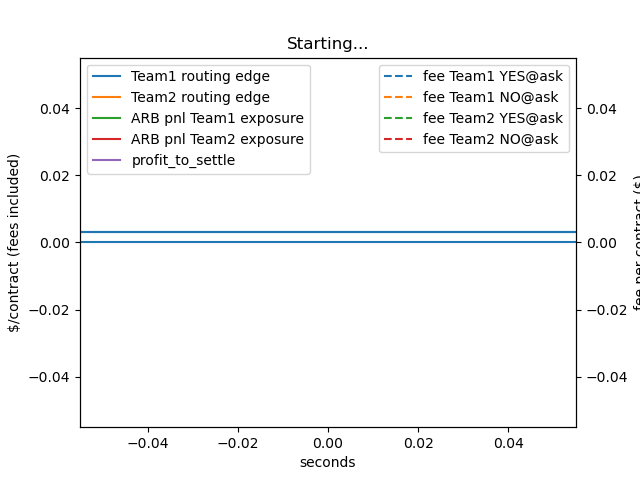

In [18]:
# Enable auto-trading with conservative parameters
mon, ani = live_plot_pair(
    target, 
    poll_period_ms=150, 
    contract_size=200,
    auto_trade=True,           # ← ENABLE AUTO-TRADING
    trade_size=2,              # trade 2 contracts at a time
    max_position=10,           # max 10 contracts per leg
    min_trade_pnl=0.003,       # only trade if pnl ≥ $0.005/contract
    arb_floor=0.003,           # arb threshold
    profit_floor=0.003,        # dutch-to-settle threshold
    entry_maker=False,
    exit_maker=False,
    min_edge=0.01
)

In [19]:
# Check current positions
print("Current Positions:")
for ticker_side, quantity in mon.positions.items():
    if quantity != 0:
        print(f"  {ticker_side}: {quantity} contracts")

Current Positions:


In [20]:
# View trade history
import pandas as pd
if mon.trade_history:
    df = pd.DataFrame(mon.trade_history)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    print(f"\nExecuted {len(df)} trades:")
    print(df[['time', 'ticker', 'side', 'action', 'quantity', 'price']].to_string(index=False))
else:
    print("No trades executed yet")

No trades executed yet
